In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.regularizers import l2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

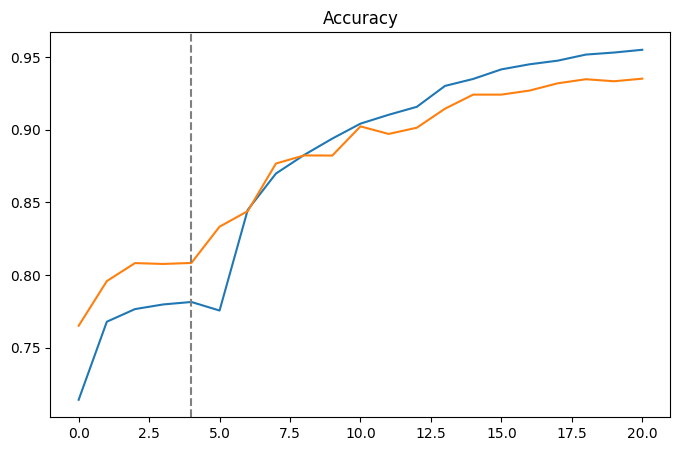

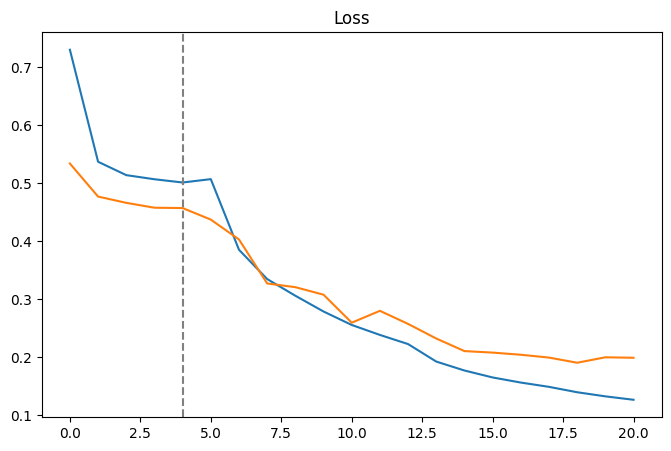

In [10]:
train_acc = [0.7140, 0.7678, 0.7765, 0.7797, 0.7814, 0.7755, 0.8449, 0.8699, 0.8827, 0.8940, 0.9043, 0.9104, 0.9159, 0.9303, 0.9351, 0.9417, 0.9452, 0.9477, 0.9519, 0.9533, 0.9552]
val_acc   = [0.7650, 0.7958, 0.8082, 0.8076, 0.8083, 0.8333, 0.8440, 0.8768, 0.8824, 0.8823, 0.9024, 0.8972, 0.9015, 0.9146, 0.9243, 0.9243, 0.9271, 0.9321, 0.9349, 0.9335, 0.9353]

train_loss = [0.7303, 0.5371, 0.5140, 0.5069, 0.5013, 0.5071, 0.3852, 0.3347, 0.3059, 0.2787, 0.2555, 0.2383, 0.2225, 0.1923, 0.1769, 0.1649, 0.1561, 0.1487, 0.1394, 0.1323, 0.1264]
val_loss   = [0.5340, 0.4770, 0.4662, 0.4578, 0.4572, 0.4373, 0.4030, 0.3271, 0.3207, 0.3077, 0.2594, 0.2799, 0.2573, 0.2321, 0.2104, 0.2078, 0.2041, 0.1992, 0.1903, 0.1997, 0.1989]

plt.figure(figsize=(8, 5))
plt.plot(train_acc)
plt.plot(val_acc)
plt.axvline(x=4, color='gray', linestyle='--')
plt.title('Accuracy')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_loss)
plt.plot(val_loss)
plt.axvline(x=4, color='gray', linestyle='--')
plt.title('Loss')
plt.show()

Found 412 files belonging to 2 classes.


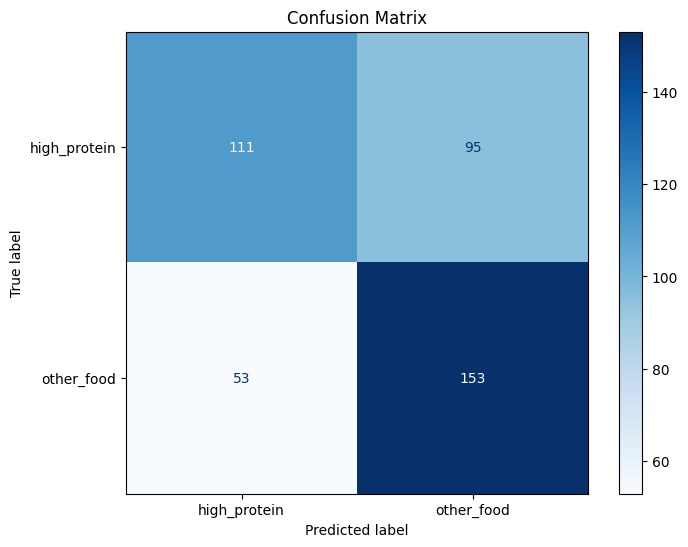

In [11]:
class_names = ['high_protein', 'other_food']

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights=None)

data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.15),
    RandomZoom(0.15),
])

model = Sequential([
    data_augmentation, 
    tf.keras.layers.Rescaling(1./127.5, offset=-1), 
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)), 
    Dropout(0.4),
    Dense(2, activation='softmax') 
])

model(tf.zeros((1, 224, 224, 3)))
model.load_weights('high_protein_food_classifier.keras')

eval_dataset = tf.keras.utils.image_dataset_from_directory(
    'binary_food_dataset/test',
    shuffle=False, 
    batch_size=32,
    image_size=(224, 224),
    label_mode='categorical'
)

true_labels = []
pred_classes = []

for images, labels in eval_dataset:
    true_labels.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(images, verbose=0)
    pred_classes.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(true_labels, pred_classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix')
plt.show()

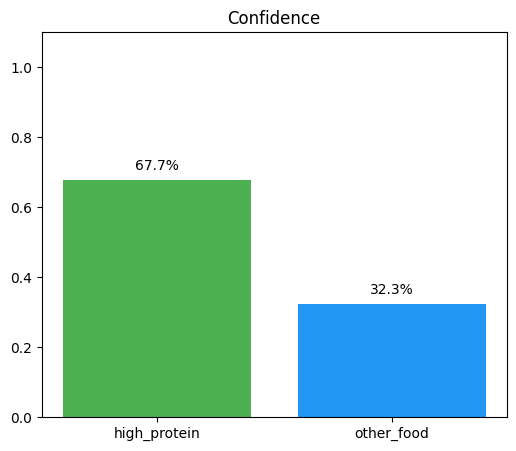

In [12]:
img = image.load_img('sample_food.jpg', target_size=(224, 224))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_batch, verbose=0)[0]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(class_names, predictions, color=['#4CAF50', '#2196F3'])
ax.set_ylim([0, 1.1])
ax.set_title('Confidence')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height*100:.1f}%', ha='center', va='bottom')

plt.show()